In [1]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [2]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [3]:
print(train.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


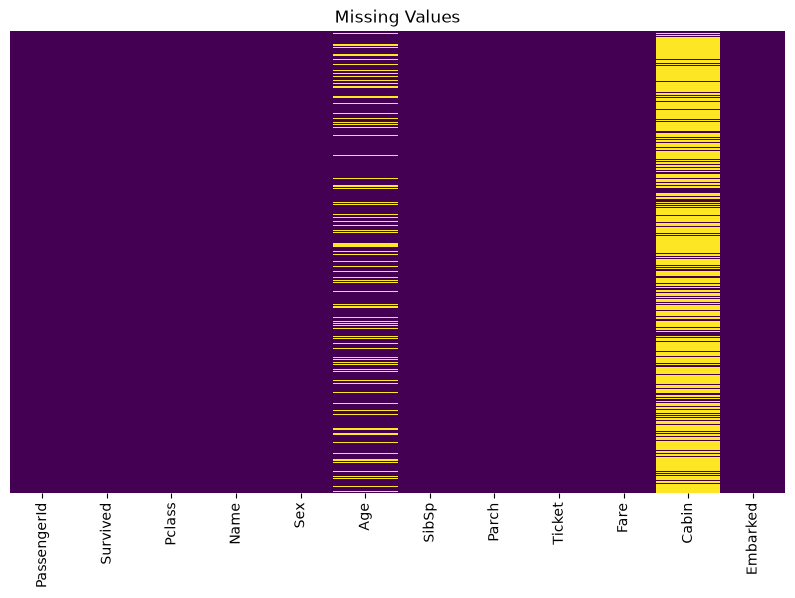

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap="viridis")

plt.title("Missing Values")
plt.show()

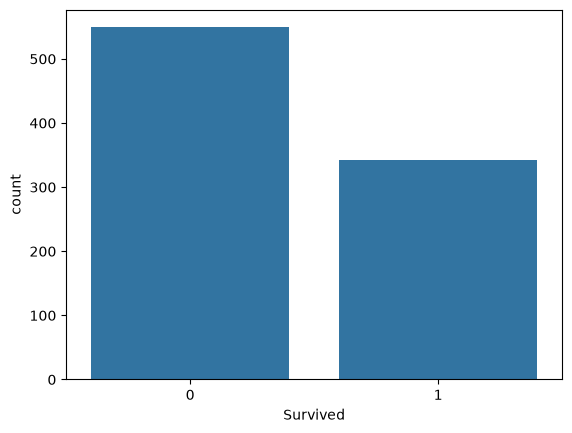

In [5]:
sns.countplot(data=train, x="Survived")
plt.show()

In [6]:
print(train["Survived"].value_counts(normalize=True))

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


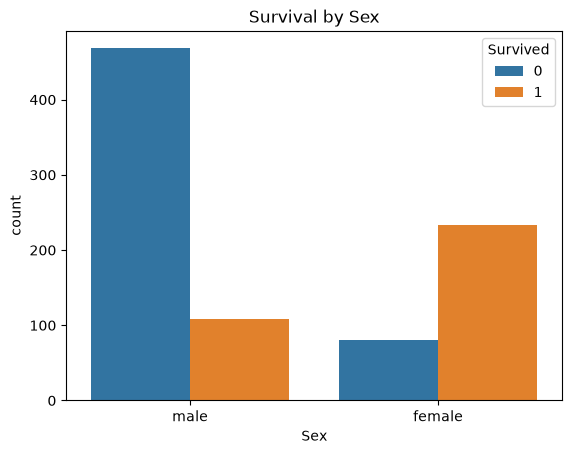

In [7]:
sns.countplot(data=train, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.show()

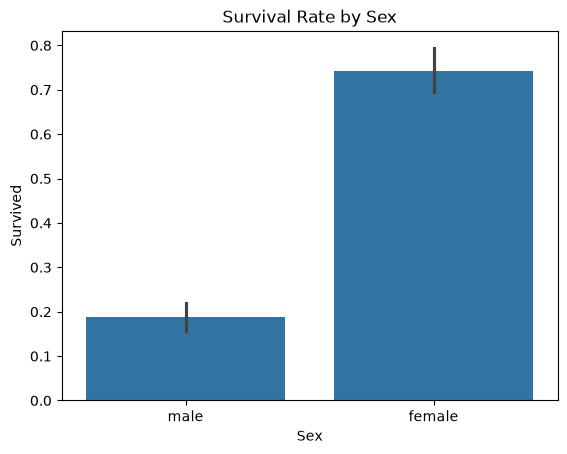

In [8]:
sns.barplot(data=train, x="Sex", y="Survived")
plt.title("Survival Rate by Sex")
plt.show()

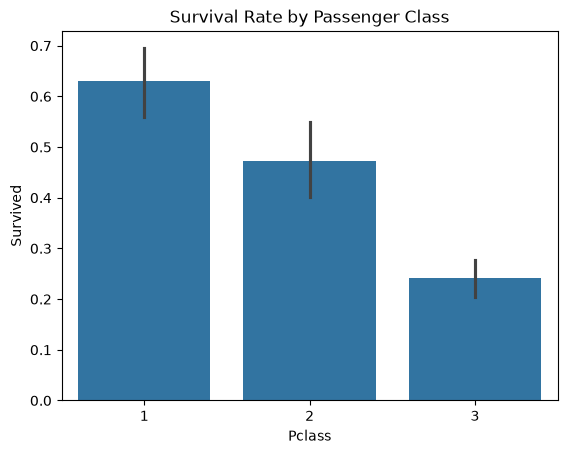

In [9]:
sns.barplot(data=train, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.show()

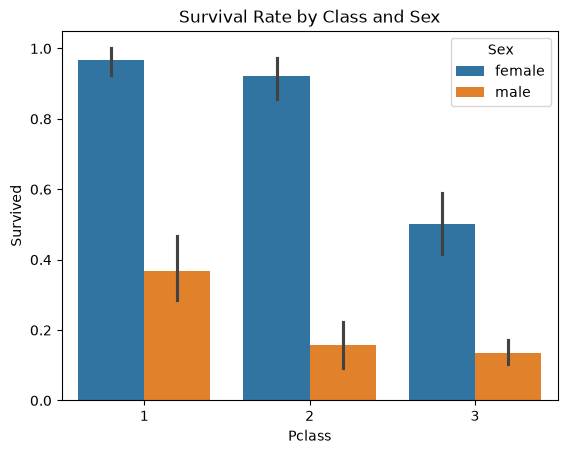

In [10]:
sns.barplot(data=train, x="Pclass", y="Survived", hue="Sex")
plt.title("Survival Rate by Class and Sex")
plt.show()

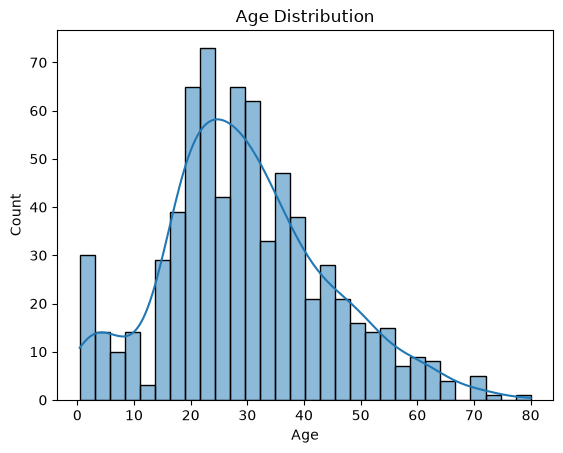

In [11]:
sns.histplot(data=train, x="Age", bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

Text(0.5, 1.0, 'Age Distribution by Survival')

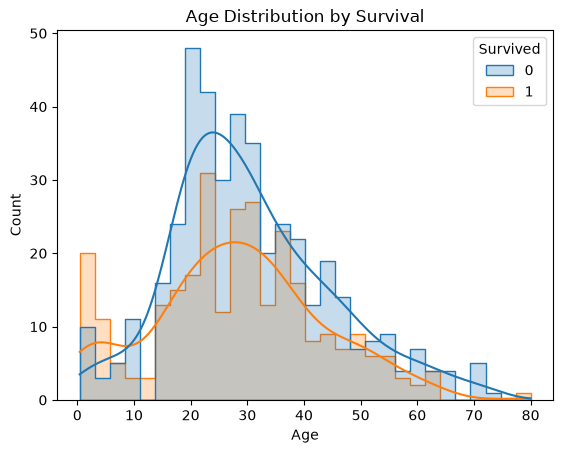

In [12]:
sns.histplot(data=train, x="Age", hue="Survived", bins=30, kde=True, element="step")
plt.title("Age Distribution by Survival")

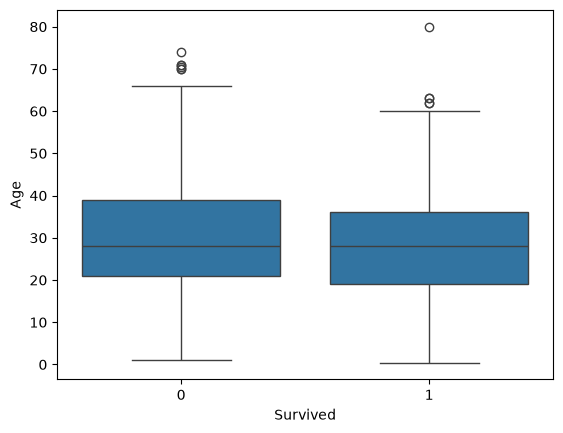

In [13]:
sns.boxplot(data=train, x="Survived", y="Age")
plt.show()

<Axes: xlabel='Fare', ylabel='Count'>

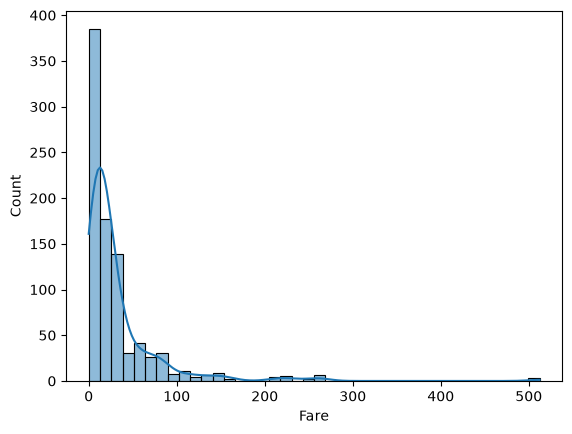

In [14]:
sns.histplot(data=train, x="Fare", bins=40, kde=True)

<Axes: xlabel='Survived', ylabel='Fare'>

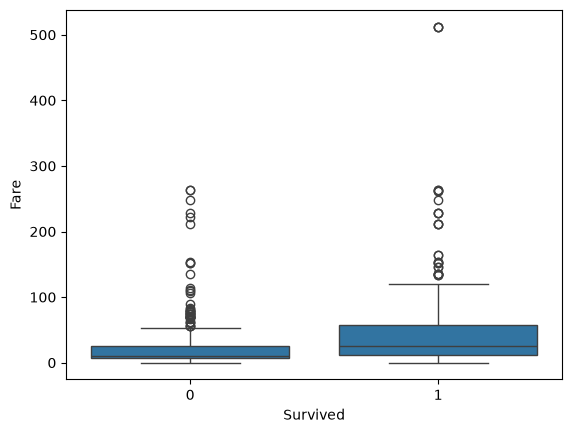

In [15]:
sns.boxplot(data=train, x="Survived", y="Fare")

In [16]:
import numpy as np
train["LogFare"] = np.log1p(train["Fare"])

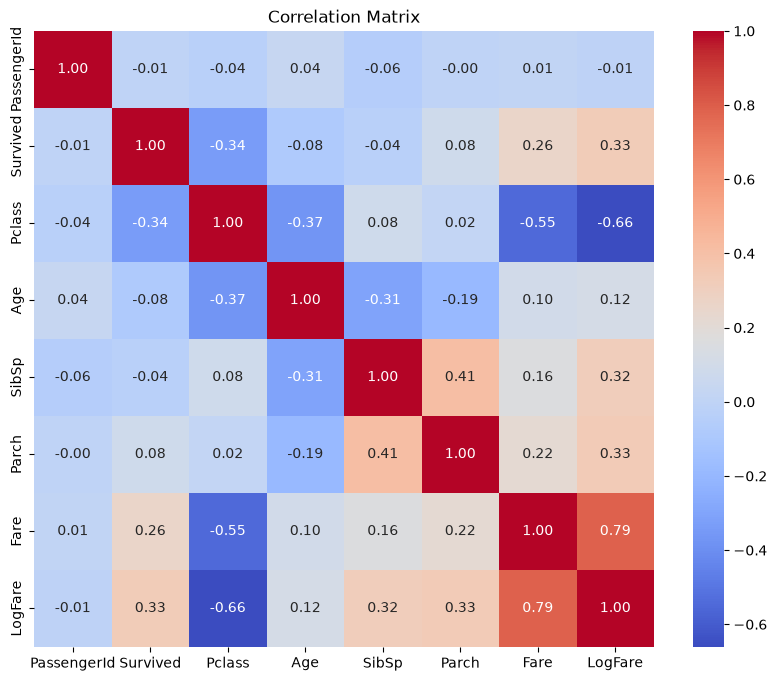

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(train.select_dtypes("number").corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [18]:
drop_columns = [
    "PassengerId",
]

test_column = ["Survived"]

X = train.drop(columns=drop_columns+test_column)
y = train['Survived']

test_id = test['PassengerId']
X_test_final = test.drop(columns='PassengerId')

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 11), (179, 11), (712,), (179,))

In [20]:
from sklearn.preprocessing import StandardScaler

# Scale for lr, knn, svm, nn

In [21]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]
# Pclass

from sklearn.preprocessing import OneHotEncoder
categorical_features = [
    "Sex",
    "Embarked"
]

# Special considerations; Ticket, Cabin

numeric_features_fe = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Pclass",
    "FamilySize",
    "IsAlone",
    "IsChild",
    "CabinKnown",
    "FarePerPerson"
]

categorical_features_fe = [
    "Sex",
    "Embarked",
    "Title",
    "TicketPrefix"
]

more_numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Pclass",
    "FamilySize",
    "IsAlone",
    "IsChild",
    "IsMother",
    "CabinKnown",
    "FarePerPerson",
    "TicketGroupSize"
]

more_categorical_features = [
    "Sex",
    "Embarked",
    "Title",
    "TicketPrefix",
    "CabinDeck",
    "AgeGroup"
]

more_drop_columns = [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin"
]

In [22]:
def feature_engineering(df):
    df = df.copy()

    df["FamilySize"] = (
        df["SibSp"] +
        df["Parch"] +
        1
    )

    df["IsAlone"] = (
        df["FamilySize"] == 1
    ).astype(int)

    df["Title"] = (
        df["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )

    common_titles = [
        "Mr",
        "Miss",
        "Mrs",
        "Master"
    ]

    df["Title"] = df["Title"].where(
        df["Title"].isin(common_titles),
        "Rare"
    )

    df["IsChild"] = (
        df["Age"] < 16
    ).astype(int)

    df["CabinKnown"] = (
        df["Cabin"].notna()
    ).astype(int)

    df["TicketPrefix"] = (
        df["Ticket"]
        .str.replace(r"\d", "", regex=True)
        .str.replace(r"[./]", "", regex=True)
        .str.replace(" ", "", regex=False)
    )

    df["TicketPrefix"] = df["TicketPrefix"].replace(
        "",
        "NONE"
    )

    df["FarePerPerson"] = (
        df["Fare"] /
        df["FamilySize"]
    )

    return df


In [23]:
X_fe = feature_engineering(X)
X_fe = X_fe.drop(columns=["Name", "Ticket", "Cabin"])
X_fe.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,LogFare,FamilySize,IsAlone,Title,IsChild,CabinKnown,TicketPrefix,FarePerPerson
0,3,male,22.0,1,0,7.2500,S,2.110213,2,0,Mr,0,0,A,3.62500
1,1,female,38.0,1,0,71.2833,C,4.280593,2,0,Mrs,0,1,PC,35.64165
2,3,female,26.0,0,0,7.9250,S,2.188856,1,1,Miss,0,0,STONO,7.92500
3,1,female,35.0,1,0,53.1000,S,3.990834,2,0,Mrs,0,1,NONE,26.55000
4,3,male,35.0,0,0,8.0500,S,2.202765,1,1,Mr,0,0,NONE,8.05000


In [24]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe,y, test_size=0.2, random_state=42)
X_train_fe.shape, X_test_fe.shape, y_train_fe.shape, y_test_fe.shape

((712, 15), (179, 15), (712,), (179,))

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

In [26]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_lr = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor_lr_fe = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features_fe),
    ("cat", categorical_pipeline, categorical_features_fe)
])

numeric_pipeline_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_tree = ColumnTransformer([
    ("num", numeric_pipeline_tree, numeric_features_fe),
    ("cat", categorical_pipeline, categorical_features_fe)
])

In [27]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cvr = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

In [28]:
def more_feature_engineering(df):
    df = df.copy()

    # -------------------------
    # Family features
    # -------------------------
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    df["IsAlone"] = (
        df["FamilySize"] == 1
    ).astype(int)

    # -------------------------
    # Title
    # -------------------------
    df["Title"] = (
        df["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )

    common_titles = ["Mr", "Miss", "Mrs", "Master"]

    df["Title"] = df["Title"].where(
        df["Title"].isin(common_titles),
        "Rare"
    )

    # -------------------------
    # Age
    # -------------------------
    df["IsChild"] = (
        df["Age"] < 16
    ).astype(int)

    df["IsMother"] = (
        (df["Sex"] == "female") &
        (df["Parch"] > 0) &
        (df["Age"] > 18) &
        (df["Title"] == "Mrs")
    ).astype(int)

    # Age groups
    df["AgeGroup"] = pd.cut(
        df["Age"],
        bins=[0, 5, 12, 18, 30, 50, 100],
        labels=[
            "Baby",
            "Child",
            "Teen",
            "YoungAdult",
            "Adult",
            "Senior"
        ]
    )

    # -------------------------
    # Cabin
    # -------------------------
    df["CabinKnown"] = (
        df["Cabin"].notna()
    ).astype(int)

    df["CabinDeck"] = (
        df["Cabin"]
        .fillna("Unknown")
        .str[0]
    )

    # -------------------------
    # Ticket
    # -------------------------
    df["TicketPrefix"] = (
        df["Ticket"]
        .str.replace(r"\d", "", regex=True)
        .str.replace(r"[./]", "", regex=True)
        .str.replace(" ", "", regex=False)
    )

    df["TicketPrefix"] = df["TicketPrefix"].replace(
        "",
        "NONE"
    )

    # Ticket frequency
    ticket_counts = df["Ticket"].value_counts()

    df["TicketGroupSize"] = (
        df["Ticket"].map(ticket_counts)
    )

    # -------------------------
    # Fare
    # -------------------------
    df["FarePerPerson"] = (
        df["Fare"] / df["FamilySize"]
    )

    return df

***1. LOGISTIC REGRESSION***

In [29]:
from sklearn.linear_model import LogisticRegression

model_lr = Pipeline([
    ("preprocessor", preprocessor_lr_fe),
    ("model", LogisticRegression(
        max_iter=2000,
        C=1.0
    ))
])

***2. KNN***

In [30]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = Pipeline([
    ("preprocessor", preprocessor_lr_fe),
    ("model", KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        p=2
    ))
])

***3. DECISION TREE***

In [31]:
from sklearn.tree import DecisionTreeClassifier

model_dt = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42
    ))
])

***4. RANDOM FOREST***

In [32]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=7,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

***5. GRADIENT BOOSTING***

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=5,
        random_state=42
    ))
])

***6. XG BOOST***

In [34]:
from xgboost import XGBClassifier

model_xgb = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

***7. LIGHT GBM***

In [35]:
from lightgbm import LGBMClassifier

model_lgbm = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=15,
        max_depth=4,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

***8. CAT BOOST***

In [36]:
from catboost import CatBoostClassifier

model_cat = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", CatBoostClassifier(
        iterations=300,
        learning_rate=0.03,
        depth=4,
        l2_leaf_reg=5,
        loss_function="Logloss",
        verbose=False,
        random_seed=42,
        allow_writing_files=False
    ))
])

***8.1 NATIVE CAT BOOST***

In [62]:
def cat_feature_engineering(df):
    df = df.copy()

    df["FamilySize"] = (
        df["SibSp"] +
        df["Parch"] +
        1
    )

    df["IsAlone"] = (
        df["FamilySize"] == 1
    ).astype(int)

    df["Title"] = (
        df["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )

    common_titles = [
        "Mr",
        "Miss",
        "Mrs",
        "Master"
    ]

    df["Title"] = df["Title"].where(
        df["Title"].isin(common_titles),
        "Rare"
    )

    df["IsChild"] = (
        df["Age"] < 16
    ).astype(int)

    df["CabinKnown"] = (
        df["Cabin"].notna()
    ).astype(int)

    df["Deck"] = (
        df["Cabin"]
        .str[0]
        .fillna("Unknown")
    )

    df["TicketPrefix"] = (
        df["Ticket"]
        .str.replace(r"\d", "", regex=True)
        .str.replace(r"[./]", "", regex=True)
        .str.replace(" ", "", regex=False)
    )

    df["TicketPrefix"] = df["TicketPrefix"].replace(
        "",
        "NONE"
    )

    df["FarePerPerson"] = (
        df["Fare"] /
        df["FamilySize"]
    )

    return df


In [63]:
X_cat = cat_feature_engineering(X)

X_cat = X_cat.drop(
    columns=["Name", "Ticket", "Cabin"]
)

cat_features = (
    "Sex",
    "Embarked",
    "Title",
    "TicketPrefix"
)

categorical_features_cat = (
    "Sex",
    "Embarked",
    "Title",
    "TicketPrefix",
    "Deck"
)


X_cat[list(categorical_features_cat)] = (
    X_cat[list(categorical_features_cat)]
    .fillna("Missing")
    .astype(str)
)


In [64]:
model_cat_native = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    cat_features=categorical_features_cat
)


In [65]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

scores_cat = cross_validate(
    model_cat_native,
    X_cat,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

print("Accuracy:", scores_cat["test_accuracy"].mean())
print("Precision:", scores_cat["test_precision"].mean())
print("Recall:", scores_cat["test_recall"].mean())
print("F1:", scores_cat["test_f1"].mean())
print("ROC-AUC:", scores_cat["test_roc_auc"].mean())


Accuracy: 0.8271483271608814
Precision: 0.7846698358830712
Recall: 0.757161125319693
F1: 0.7703834723704535
ROC-AUC: 0.87539285366393


***9. NEURAL NETWORK***

In [66]:
from sklearn.neural_network import MLPClassifier

model_nn = Pipeline([
    ("preprocessor", preprocessor_lr_fe),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    ))
])

In [67]:
models = {
    "Logistic Regression": model_lr,
    "KNN": model_knn,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "Gradient Boosting": model_gb,
    "XGBoost": model_xgb,
    "LightGBM": model_lgbm,
    "CatBoost": model_cat,
    "Neural Network": model_nn
}

In [68]:
import pandas as pd
import numpy as np

results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_fe,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std(),
        "Min": scores.min(),
        "Max": scores.max()
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "Mean Accuracy",
        ascending=False
    )
)

results_df

,Model,Mean Accuracy,Std,Min,Max
5,XGBoost,0.843977,0.013199,0.825843,0.860335
6,LightGBM,0.838365,0.013676,0.814607,0.854749
3,Random Forest,0.837242,0.014840,0.814607,0.854749
4,Gradient Boosting,0.837229,0.018005,0.814607,0.865922
7,CatBoost,0.833884,0.009306,0.820225,0.843575
2,Decision Tree,0.831605,0.025844,0.797753,0.871508
0,Logistic Regression,0.824895,0.011185,0.814607,0.843575
1,KNN,0.805800,0.021763,0.775281,0.837989
8,Neural Network,0.787885,0.011868,0.769663,0.803371


In [69]:
from sklearn.model_selection import cross_validate

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_fe,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy", ascending=False)
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
5,XGBoost,0.843977,0.822511,0.757161,0.787941,0.881564
6,LightGBM,0.838365,0.814036,0.751492,0.781109,0.884873
3,Random Forest,0.837242,0.827140,0.727835,0.773880,0.879912
4,Gradient Boosting,0.837229,0.806582,0.760060,0.781779,0.884256
7,CatBoost,0.833884,0.819278,0.728005,0.770596,0.884298
2,Decision Tree,0.831605,0.800457,0.756948,0.774270,0.868244
0,Logistic Regression,0.824895,0.787648,0.745396,0.765302,0.872750
1,KNN,0.805800,0.743492,0.757246,0.749707,0.852396
8,Neural Network,0.787885,0.801384,0.599361,0.683524,0.849458


***10. VOTING***

In [70]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("lr", model_lr),
        ("rf", model_rf),
        ("gb", model_gb),
        ("xgb", model_xgb),
        ("cat", model_cat)
    ],
    voting="soft"
)

In [71]:
scores_voting = cross_val_score(
    voting_model,
    X_fe,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print(scores_voting)
print(scores_voting.mean())
print(scores_voting.std())

[0.8547486  0.83146067 0.8258427  0.84831461 0.85393258]
0.8428598330299417
0.011943424888331493


In [72]:
weighted_voting_model = VotingClassifier(
    estimators=[
        ("lr", model_lr),
        ("rf", model_rf),
        ("gb", model_gb),
        ("xgb", model_xgb),
        ("cat", model_cat)
    ],
    voting="soft",
    weights=[1, 1, 2, 4, 2],
    n_jobs=-1
)


In [73]:
weighted_scores_voting = cross_val_score(
    voting_model,
    X_fe,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print(weighted_scores_voting)
print(weighted_scores_voting.mean())
print(weighted_scores_voting.std())

[0.8547486  0.83146067 0.8258427  0.84831461 0.85393258]
0.8428598330299417
0.011943424888331493


***11. STACKING***

In [74]:
from sklearn.ensemble import StackingClassifier

stacking_model = StackingClassifier(
    estimators=[
        ("lr", model_lr),
        ("rf", model_rf),
        ("gb", model_gb),
        ("xgb", model_xgb),
        ("cat", model_cat)
    ],
    final_estimator=LogisticRegression(
        max_iter=2000
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

In [75]:
scores_stack = cross_val_score(
    stacking_model,
    X_fe,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print(scores_stack)
print("Mean:", scores_stack.mean())
print("Std:", scores_stack.std())

[0.8547486  0.83707865 0.82022472 0.84831461 0.84269663]
Mean: 0.8406126420187057
Std: 0.011761336272759423


***12. BLENDING***

In [76]:
models_to_blend = {
    "lr": model_lr,
    "rf": model_rf,
    "gb": model_gb,
    "xgb": model_xgb,
    "lgbm": model_lgbm,
    "cat": model_cat
}

In [77]:
from sklearn.model_selection import cross_val_predict

pred_lr = cross_val_predict(
    model_lr,
    X_fe,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

pred_rf = cross_val_predict(
    model_rf,
    X_fe,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

pred_xgb = cross_val_predict(
    model_xgb,
    X_fe,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

pred_cat = cross_val_predict(
    model_cat,
    X_fe,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

pred_gb = cross_val_predict(
    model_gb,
    X_fe,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

pred_lgbm = cross_val_predict(
    model_lgbm,
    X_fe,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


In [78]:
blend_probability = (
    0.20 * pred_lr +
    0.25 * pred_rf +
    0.30 * pred_xgb +
    0.25 * pred_cat
)

final_prediction = (
    blend_probability >= 0.5
).astype(int)

blend_accuracy = (final_prediction == y).mean()

print("Blend accuracy:", blend_accuracy)


Blend accuracy: 0.8406285072951739


In [87]:
import numpy as np

best_accuracy = 0
best_weights = None

for w_xgb in np.arange(0.0, 0.61, 0.05):
    for w_cat in np.arange(0.0, 0.51, 0.05):
        for w_lgbm in np.arange(0.0, 0.51, 0.05):

            w_lr = 1.0 - w_xgb - w_cat - w_lgbm

            if w_lr < 0:
                continue

            blend = (
                w_lr * pred_lr +
                w_xgb * pred_xgb +
                w_cat * pred_cat +
                w_lgbm * pred_lgbm
            )

            pred = (blend >= 0.48).astype(int)

            acc = (pred == y).mean()

            if acc > best_accuracy:
                best_accuracy = acc
                best_weights = {
                    "lr": w_lr,
                    "xgb": w_xgb,
                    "cat": w_cat,
                    "lgbm": w_lgbm
                }

print(best_accuracy)
print(best_weights)


0.8496071829405163
{'lr': np.float64(0.1999999999999999), 'xgb': np.float64(0.4), 'cat': np.float64(0.05), 'lgbm': np.float64(0.35000000000000003)}


In [80]:
thresholds = np.arange(0.30, 0.71, 0.01)

best_threshold = 0.5
best_accuracy = 0

for threshold in thresholds:

    pred = (
        blend_probability >= threshold
    ).astype(int)

    accuracy = (
        pred == y
    ).mean()

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best OOF accuracy:", best_accuracy)


Best threshold: 0.48000000000000015
Best OOF accuracy: 0.8417508417508418


In [81]:
thresholds = np.arange(0.30, 0.71, 0.01)

best_threshold = 0.5
best_accuracy = 0

for threshold in thresholds:

    pred = (
        blend_probability >= threshold
    ).astype(int)

    accuracy = (
        pred == y
    ).mean()

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best OOF accuracy:", best_accuracy)


Best threshold: 0.48000000000000015
Best OOF accuracy: 0.8417508417508418


In [82]:
oof_preds = pd.DataFrame({
    "LR": pred_lr,
    "RF": pred_rf,
    "XGB": pred_xgb,
    "LGBM": pred_lgbm,
    "CAT": pred_cat
})

print(oof_preds.corr())


            LR        RF       XGB      LGBM       CAT
LR    1.000000  0.959775  0.943635  0.919919  0.957747
RF    0.959775  1.000000  0.973632  0.961109  0.984459
XGB   0.943635  0.973632  1.000000  0.986336  0.981527
LGBM  0.919919  0.961109  0.986336  1.000000  0.974408
CAT   0.957747  0.984459  0.981527  0.974408  1.000000


In [83]:
y_pred_xgb = (pred_xgb >= 0.5).astype(int)
y_pred_lgbm = (pred_lgbm >= 0.5).astype(int)
y_pred_lr = (pred_lr >= 0.5).astype(int)
y_pred_cat = (pred_cat >= 0.5).astype(int)

error_df = pd.DataFrame({
    "LR": y_pred_lr != y,
    "XGB": y_pred_xgb != y,
    "LGBM": y_pred_lgbm != y,
    "CAT": y_pred_cat != y
})

print(error_df.corr())


            LR       XGB      LGBM       CAT
LR    1.000000  0.721605  0.624083  0.817999
XGB   0.721605  1.000000  0.827965  0.813709
LGBM  0.624083  0.827965  1.000000  0.770747
CAT   0.817999  0.813709  0.770747  1.000000


In [84]:
blend_lr_lgbm = (
    0.5 * pred_lr +
    0.5 * pred_lgbm
)

acc = (
    (blend_lr_lgbm >= 0.5).astype(int) == y
).mean()

print(acc)


0.8451178451178452


In [85]:
blend_xgb_lgbm = (
    0.5 * pred_xgb +
    0.5 * pred_lgbm
)

acc = (
    (blend_xgb_lgbm >= 0.5).astype(int) == y
).mean()

print(acc)


0.8451178451178452


In [86]:
blend_xgb_lr = (
    0.5 * pred_xgb +
    0.5 * pred_lr
)

acc = (
    (blend_xgb_lr >= 0.5).astype(int) == y
).mean()

print(acc)


0.8361391694725028


In [88]:
X_final = feature_engineering(X)
X_test_final = feature_engineering(test)


In [89]:
X_final = X_final.drop(
    columns=["Name", "Ticket", "Cabin"]
)


test_id = test['PassengerId']
X_test_final = X_test_final.drop(
    columns=["Name", "Ticket", "Cabin", "PassengerId"]
)


In [90]:
X_test_final.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,IsChild,CabinKnown,TicketPrefix,FarePerPerson
0,3,male,34.5,0,0,7.8292,Q,1,1,Mr,0,0,NONE,7.829200
1,3,female,47.0,1,0,7.0000,S,2,0,Mrs,0,0,NONE,3.500000
2,2,male,62.0,0,0,9.6875,Q,1,1,Mr,0,0,NONE,9.687500
3,3,male,27.0,0,0,8.6625,S,1,1,Mr,0,0,NONE,8.662500
4,3,female,22.0,1,1,12.2875,S,3,0,Mrs,0,0,NONE,4.095833


***SUBMISSION 1***

In [91]:
model_xgb.fit(X_final, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Pclass','Sex','Age',...,'CabinKnown','TicketPrefix','FarePerPerson']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [92]:
pred_xgb_test = model_xgb.predict_proba(
    X_test_final
)[:, 1]

In [93]:
prediction_xgb = (
    pred_xgb_test >= 0.5
).astype(int)

***SUBMISSION 2***

In [94]:
model_lgbm.fit(X_final, y)

pred_lgbm_test = model_lgbm.predict_proba(
    X_test_final
)[:, 1]

prediction_lgbm = (
    pred_lgbm_test >= 0.5
).astype(int)

In [95]:
model_lr.fit(X_final, y)

pred_lr_test = model_lr.predict_proba(
    X_test_final
)[:, 1]

In [96]:
prediction_lr = (
    pred_lr_test >= 0.5
).astype(int)

***SUBMISSION 1***

In [97]:
blend_test_probability = (
    0.50 * pred_lr_test +
    0.50 * pred_lgbm_test
)

prediction_blend = (
    blend_test_probability >= 0.5
).astype(int)

***SUBMISSION 2***

In [98]:
blend_xgb_lgbm_probability = (
    0.50 * pred_xgb_test +
    0.50 * pred_lgbm_test
)

prediction_xgb_lgbm = (
    blend_xgb_lgbm_probability >= 0.5
).astype(int)


***SUBMISSION FILE FOR XG BOOST***

In [99]:
submission_xgb = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": prediction_xgb
})

submission_xgb.to_csv(
    "submission_xgb.csv",
    index=False
)

***SUBMISSION FILE FOR LR+LGBM***

In [100]:
submission_lr_lgbm = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": prediction_blend
})

submission_lr_lgbm.to_csv(
    "submission_lr_lgbm.csv",
    index=False
)

***SUBMISSION FILE FOR XGB + LGBM***

In [101]:
submission_xgb_lgbm = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": prediction_xgb_lgbm
})

submission_xgb_lgbm.to_csv(
    "submission_xgb_lgbm.csv",
    index=False
)

***SUBMISSION CHECKS***

In [104]:
print(submission_xgb.head())
print(submission_xgb.shape)
print(submission_xgb["Survived"].value_counts())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
(418, 2)
Survived
0    260
1    158
Name: count, dtype: int64


In [105]:
assert submission_xgb["PassengerId"].equals(
    test["PassengerId"]
)

assert submission_xgb["Survived"].isin([0, 1]).all()


In [106]:
print(submission_lr_lgbm.head())
print(submission_lr_lgbm.shape)
print(submission_lr_lgbm["Survived"].value_counts())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
(418, 2)
Survived
0    257
1    161
Name: count, dtype: int64


In [107]:
assert submission_lr_lgbm["PassengerId"].equals(
    test["PassengerId"]
)

assert submission_lr_lgbm["Survived"].isin([0, 1]).all()

In [108]:
print(submission_xgb_lgbm.head())
print(submission_xgb_lgbm.shape)
print(submission_xgb_lgbm["Survived"].value_counts())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
(418, 2)
Survived
0    258
1    160
Name: count, dtype: int64


In [109]:
assert submission_xgb_lgbm["PassengerId"].equals(
    test["PassengerId"]
)

assert submission_xgb_lgbm["Survived"].isin([0, 1]).all()

***SUBMISSION 4***

In [110]:
# ============================================
# 2. Train all models on full training data
# ============================================

model_lr.fit(X_final, y)

model_xgb.fit(X_final, y)

model_cat.fit(X_final, y)

model_lgbm.fit(X_final, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Pclass','Sex','Age',...,'CabinKnown','TicketPrefix','FarePerPerson']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [111]:
# ============================================
# 3. Generate test-set probabilities
# ============================================

pred_lr_test = model_lr.predict_proba(
    X_test_final
)[:, 1]

pred_xgb_test = model_xgb.predict_proba(
    X_test_final
)[:, 1]

pred_cat_test = model_cat.predict_proba(
    X_test_final
)[:, 1]

pred_lgbm_test = model_lgbm.predict_proba(
    X_test_final
)[:, 1]


In [112]:
# ============================================
# 4. Optimized probability blend
# ============================================

blend_test_probability = (
    0.20 * pred_lr_test +
    0.40 * pred_xgb_test +
    0.05 * pred_cat_test +
    0.35 * pred_lgbm_test
)


In [113]:
# ============================================
# 5. Convert probabilities to predictions
# ============================================

final_prediction = (
    blend_test_probability >= 0.48
).astype(int)


In [114]:
print("Number of predictions:", len(final_prediction))
print("Survived:", (final_prediction == 1).sum())
print("Did not survive:", (final_prediction == 0).sum())


Number of predictions: 418
Survived: 164
Did not survive: 254


In [115]:
blend_df = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "LR": pred_lr_test,
    "XGB": pred_xgb_test,
    "CAT": pred_cat_test,
    "LGBM": pred_lgbm_test,
    "Blend": blend_test_probability,
    "Prediction": final_prediction
})

blend_df.head(20)


,PassengerId,LR,XGB,CAT,LGBM,Blend,Prediction
0,892,0.092156,0.108616,0.091460,0.068322,0.090363,0
1,893,0.574292,0.248497,0.295532,0.182943,0.293064,0
2,894,0.106460,0.060050,0.053218,0.080879,0.076280,0
3,895,0.074977,0.090289,0.104380,0.151786,0.109455,0
4,896,0.631740,0.575620,0.552358,0.605435,0.596116,1
5,897,0.131289,0.081593,0.128497,0.087905,0.096087,0
6,898,0.657224,0.572240,0.561871,0.552450,0.581792,1
7,899,0.098234,0.089132,0.137333,0.104446,0.098722,0
8,900,0.845131,0.875208,0.714848,0.931297,0.880806,1
9,901,0.029462,0.052831,0.091025,0.050121,0.049118,0


In [116]:
# ============================================
# 6. Create submission dataframe
# ============================================

submission_optimized = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": final_prediction
})

print(submission_optimized.head())
print(submission_optimized.shape)
print(submission_optimized["Survived"].value_counts())


   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
(418, 2)
Survived
0    254
1    164
Name: count, dtype: int64


In [117]:
# ============================================
# 7. Save submission
# ============================================

submission_optimized.to_csv(
    "submission_optimized_blend.csv",
    index=False
)

print("Submission saved successfully!")


Submission saved successfully!


In [118]:
assert submission_optimized.shape == (len(test), 2)

assert list(submission_optimized.columns) == [
    "PassengerId",
    "Survived"
]

assert submission_optimized["PassengerId"].equals(
    test["PassengerId"]
)

assert submission_optimized["Survived"].isin([0, 1]).all()

print("All submission checks passed.")


All submission checks passed.


In [119]:
print("Shape:", submission_optimized.shape)
print("Columns:", submission_optimized.columns.tolist())
print()
print(submission_optimized.head())


Shape: (418, 2)
Columns: ['PassengerId', 'Survived']

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
